In [ ]:
#importing weather data for Memmingen
import pandas as pd
import requests
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=weatherdataforcities&start=2019-01-01&end=2023-12-31&cityName=memmingen"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    Memm_data = response.json()

    # Convert the data to a DataFrame
    Memm_df = pd.DataFrame.from_dict(Memm_data , orient='index')

    # Reset the index to convert the timestamp to a column
    Memm_df.reset_index(inplace=True)

else:
    print("Failed to fetch data. Status code:", response.status_code)





In [ ]:

# drop unwanted columns

Memm_df = Memm_df.drop(columns = ["index", "time","snow","cityName"])
Memm_df
Memm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    43824 non-null  float64
 1   dwpt    43824 non-null  float64
 2   rhum    43824 non-null  float64
 3   prcp    43824 non-null  float64
 4   wdir    43824 non-null  float64
 5   wspd    43824 non-null  float64
 6   wpgt    43561 non-null  float64
 7   pres    43824 non-null  float64
 8   tsun    41880 non-null  float64
 9   coco    43583 non-null  float64
dtypes: float64(10)
memory usage: 3.3 MB


In [ ]:
Memm_df.head()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
0,1.2,1.2,100.0,0.0,170.0,10.1,13.0,1034.9,NaN,4.0
1,0.9,0.9,100.0,0.0,190.0,10.4,13.0,1034.6,NaN,4.0
2,1.1,1.1,100.0,0.0,180.0,13.7,13.0,1034.4,NaN,4.0
3,1.2,1.1,99.0,0.0,190.0,14.0,13.0,1034.1,0.0,4.0
4,0.4,0.3,99.0,0.0,200.0,19.8,14.8,1033.7,0.0,4.0


In [ ]:
#Checking for null values
Memm_df.isnull().sum()

temp       0
dwpt       0
rhum       0
prcp       0
wdir       0
wspd       0
wpgt     263
pres       0
tsun    1944
coco     241
dtype: int64

In [ ]:
# find the percentage of missing values in each feature
Memm_df.isnull().sum()/len(Memm_df) *100

temp    0.000000
dwpt    0.000000
rhum    0.000000
prcp    0.000000
wdir    0.000000
wspd    0.000000
wpgt    0.600128
pres    0.000000
tsun    4.435926
coco    0.549927
dtype: float64

In [ ]:
mask_nntsun = Memm_df['tsun'].isnull()
Memm_df[mask_nntsun]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
0,1.2,1.2,100.0,0.0,170.0,10.1,13.0,1034.9,NaN,4.0
1,0.9,0.9,100.0,0.0,190.0,10.4,13.0,1034.6,NaN,4.0
2,1.1,1.1,100.0,0.0,180.0,13.7,13.0,1034.4,NaN,4.0
21,2.6,1.4,92.0,0.1,230.0,21.6,42.6,1029.5,NaN,7.0
22,2.6,1.4,92.0,0.0,230.0,22.7,40.8,1029.5,NaN,7.0
...,...,...,...,...,...,...,...,...,...,...
36306,9.3,2.4,62.0,0.0,20.0,2.5,13.0,1018.4,NaN,2.0
36307,7.3,2.4,71.0,0.0,90.0,1.8,13.0,1018.7,NaN,2.0
36308,5.5,1.6,76.0,0.0,180.0,2.2,11.1,1019.0,NaN,2.0
42538,7.3,3.2,75.0,0.0,210.0,16.2,29.6,1021.5,NaN,3.0


In [ ]:
#Using Linear Regression Imputation to fill missing values in the tsun feature
from sklearn.linear_model import LinearRegression

# seperate the null  values of the tsun feature
test =  Memm_df[Memm_df["tsun"].isnull()]
X_test = test.drop(columns = ["tsun","coco","wpgt"] )

#Dropping the null values from the dataset
train = Memm_df.dropna()
#Splitting the train data into target and feature
X_train= train.drop(columns = ["tsun","coco","wpgt"])
y_train = train["tsun"]

#Calling the linear regression model
lr = LinearRegression()
#Fitting the tranining data in to the model
lr.fit(X_train, y_train)
#Predicting the missing tsun values
y_pred = lr.predict(X_test)

#Replacing the missing values with the model prediction
Memm_df.loc[Memm_df.tsun.isnull(),"tsun"] = y_pred






In [ ]:
#Check if missing values still exists for the tsun feature
Memm_df.isnull().sum()/len(Memm_df) *100

temp    0.000000
dwpt    0.000000
rhum    0.000000
prcp    0.000000
wdir    0.000000
wspd    0.000000
wpgt    0.600128
pres    0.000000
tsun    0.000000
coco    0.549927
dtype: float64

In [ ]:
from sklearn.linear_model import LinearRegression

# Separate the null values of the 'coco' feature
test_coco = Memm_df[Memm_df["coco"].isnull()]
X_test_coco = test_coco.drop(columns=["coco", "wpgt"])

# Dropping the rows with null values from the dataset
train_coco = Memm_df.dropna(subset=["coco"])
# # Splitting the training data into features and target
X_train_coco = train_coco.drop(columns=["coco", "wpgt"])
y_train_coco = train_coco["coco"]

# Calling the linear regression model
lr_coco = LinearRegression()
# Fitting the training data into the model
lr_coco.fit(X_train_coco, y_train_coco)
# Predicting the missing 'coco' values


y_pred_coco = lr_coco.predict(X_test_coco)

# Replacing the missing values with the model prediction
Memm_df.loc[Memm_df["coco"].isnull(), "coco"] = y_pred_coco



In [ ]:
from sklearn.linear_model import LinearRegression

# Separate the null values of the 'coco' feature
test_wpgt = Memm_df[Memm_df["wpgt"].isnull()]
X_test_wpgt = test_wpgt.drop(columns=["wpgt"])

# Dropping the rows with null values from the dataset
train_wpgt = Memm_df.dropna(subset=["wpgt"])
# # Splitting the training data into features and target
X_train_wpgt = train_wpgt.drop(columns=["wpgt"])
y_train_wpgt = train_wpgt["wpgt"]

# Calling the linear regression model
lr_wpgt = LinearRegression()
# Fitting the training data into the model
lr_wpgt.fit(X_train_wpgt, y_train_wpgt)
# Predicting the missing 'coco' values


y_pred_wpgt = lr_wpgt.predict(X_test_wpgt)

# Replacing the missing values with the model prediction
Memm_df.loc[Memm_df["wpgt"].isnull(), "wpgt"] = y_pred_wpgt



In [ ]:
Memm_df.isnull().sum()

temp    0
dwpt    0
rhum    0
prcp    0
wdir    0
wspd    0
wpgt    0
pres    0
tsun    0
coco    0
dtype: int64

In [ ]:
#Check if missing values still exists for the coco feature
Memm_df.isnull().sum()/len(Memm_df) *100


temp    0.0
dwpt    0.0
rhum    0.0
prcp    0.0
wdir    0.0
wspd    0.0
wpgt    0.0
pres    0.0
tsun    0.0
coco    0.0
dtype: float64

In [ ]:

Memm_df.isnull().sum()

temp    0
dwpt    0
rhum    0
prcp    0
wdir    0
wspd    0
wpgt    0
pres    0
tsun    0
coco    0
dtype: int64

In [ ]:
# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = Memm_df.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
Memm_df.describe()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,9.288942,5.228916,78.460866,0.110597,186.131344,10.245925,22.206406,1017.946737,14.517991,4.568831
std,7.933772,6.574245,17.329057,0.625964,88.057340,6.042144,10.785183,8.640883,23.015377,4.109379
min,-16.300000,-17.600000,19.000000,0.000000,0.000000,0.700000,5.500000,980.800000,-10.194093,0.075406
25%,3.000000,-0.100000,67.000000,0.000000,150.000000,5.800000,14.800000,1013.000000,0.000000,2.000000
50%,9.000000,5.200000,84.000000,0.000000,200.000000,9.000000,18.500000,1018.000000,0.000000,3.000000
75%,14.900000,10.800000,93.000000,0.000000,230.000000,13.700000,25.900000,1022.900000,26.000000,5.000000
max,33.700000,21.600000,100.000000,33.900000,360.000000,49.300000,88.900000,1045.700000,60.000000,25.000000


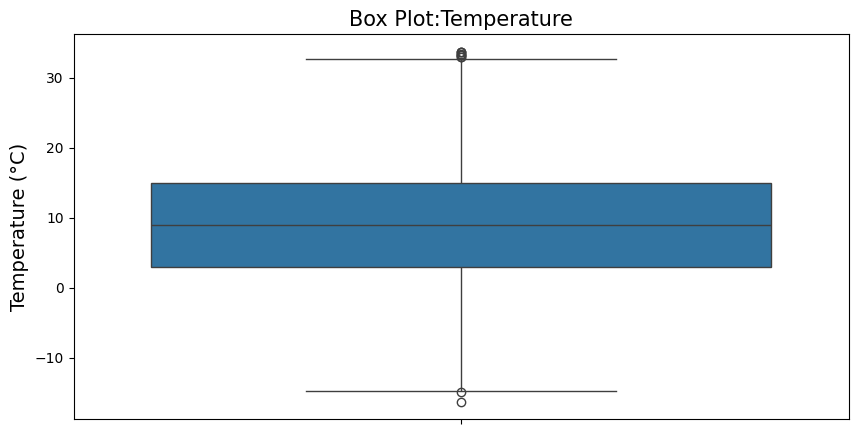

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.temp)
plt.title('Box Plot:Temperature', fontsize=15)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.show()

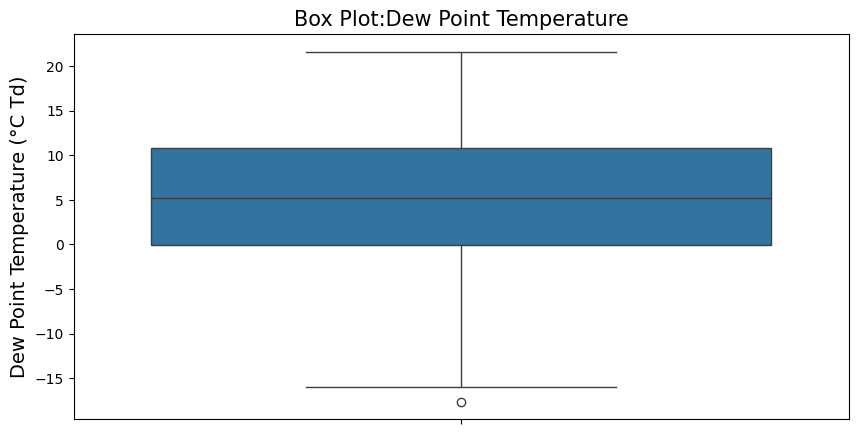

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.dwpt)
plt.title('Box Plot:Dew Point Temperature', fontsize=15)
plt.ylabel('Dew Point Temperature (°C Td)', fontsize=14)
plt.show()

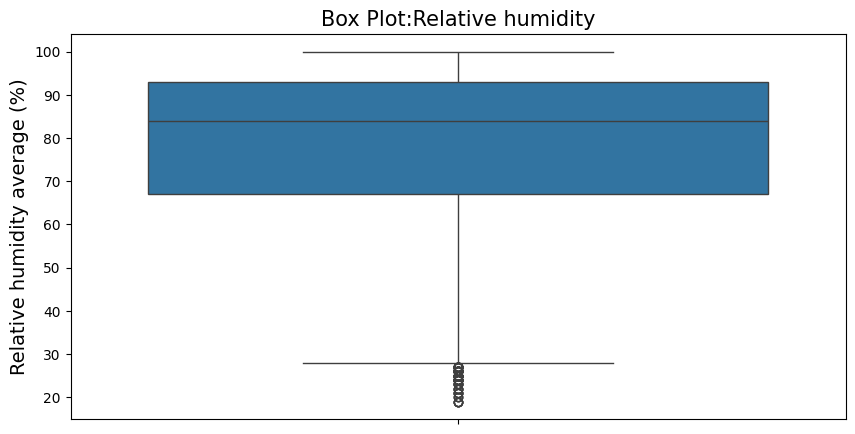

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.rhum)
plt.title('Box Plot:Relative humidity', fontsize=15)
plt.ylabel('Relative humidity average (%)', fontsize=14)
plt.show()

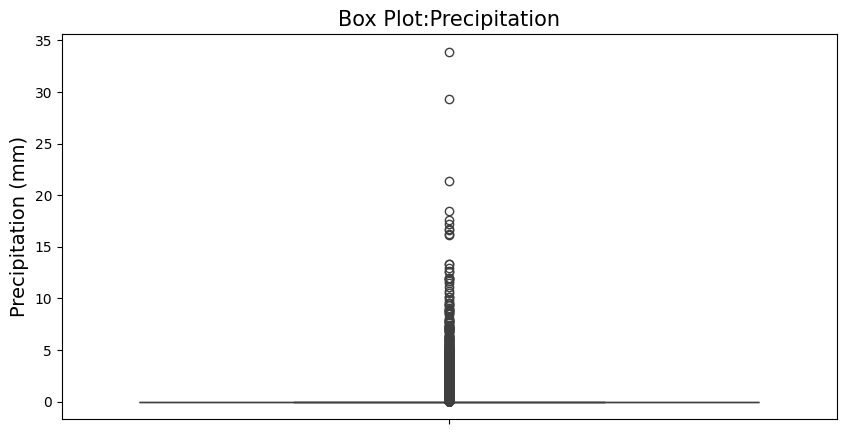

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.prcp)
plt.title('Box Plot:Precipitation', fontsize=15)
plt.ylabel('Precipitation (mm)', fontsize=14)
plt.show()

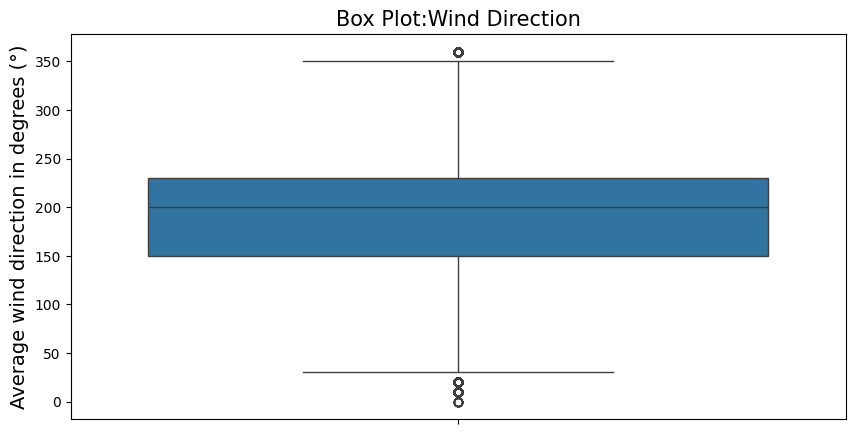

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.wdir)
plt.title('Box Plot:Wind Direction', fontsize=15)
plt.ylabel('Average wind direction in degrees (°)', fontsize=14)
plt.show()

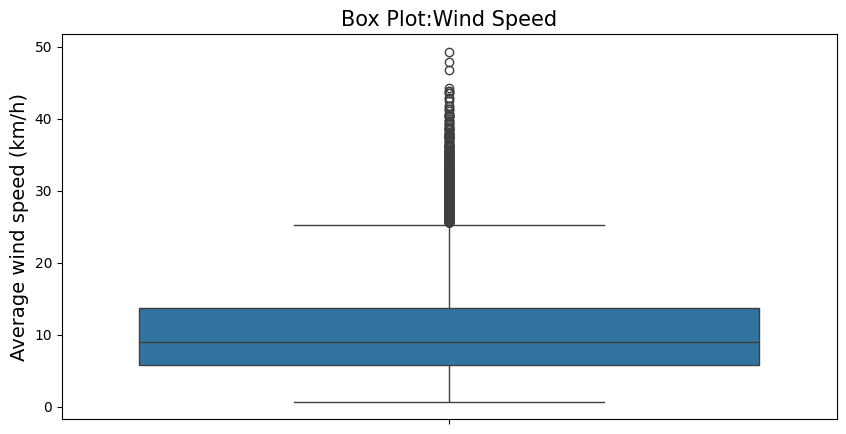

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.wspd)
plt.title('Box Plot:Wind Speed', fontsize=15)
plt.ylabel('Average wind speed (km/h)', fontsize=14)
plt.show()

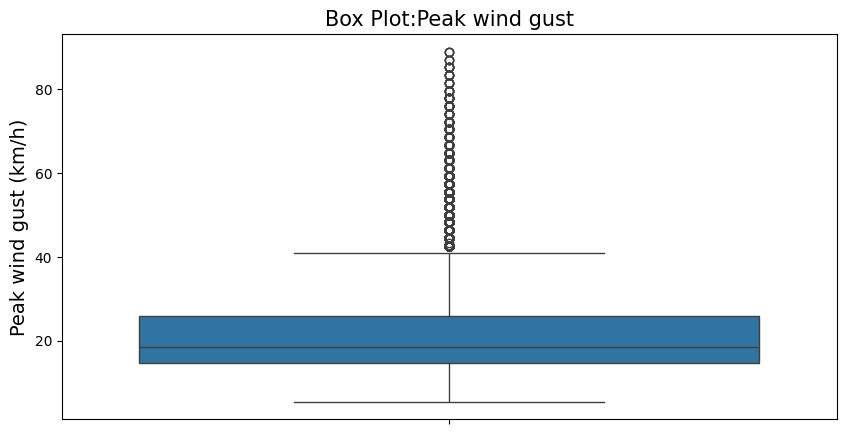

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.wpgt)
plt.title('Box Plot:Peak wind gust', fontsize=15)
plt.ylabel('Peak wind gust (km/h)', fontsize=14)
plt.show()

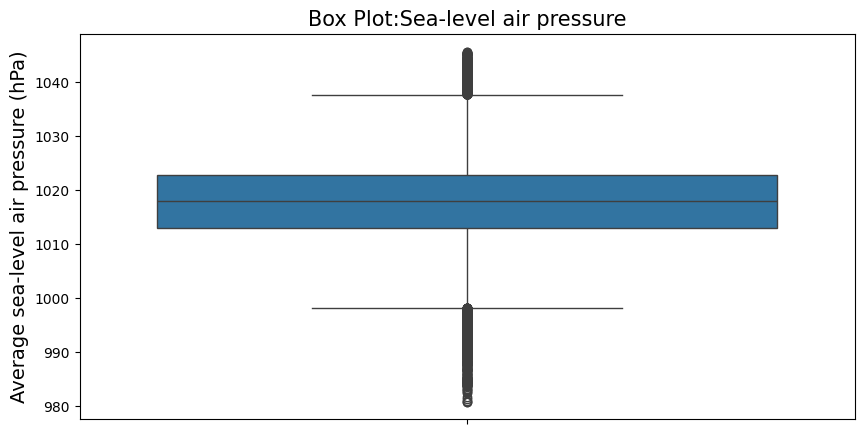

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.pres)
plt.title('Box Plot:Sea-level air pressure', fontsize=15)
plt.ylabel('Average sea-level air pressure (hPa)', fontsize=14)
plt.show()

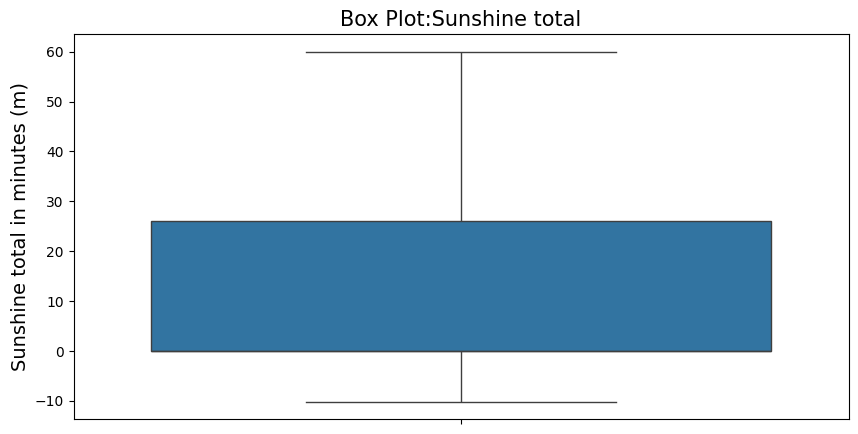

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.tsun)
plt.title('Box Plot:Sunshine total', fontsize=15)
plt.ylabel('Sunshine total in minutes (m)', fontsize=14)
plt.show()

In [ ]:
Memm_df["tsun"].max()

60.0

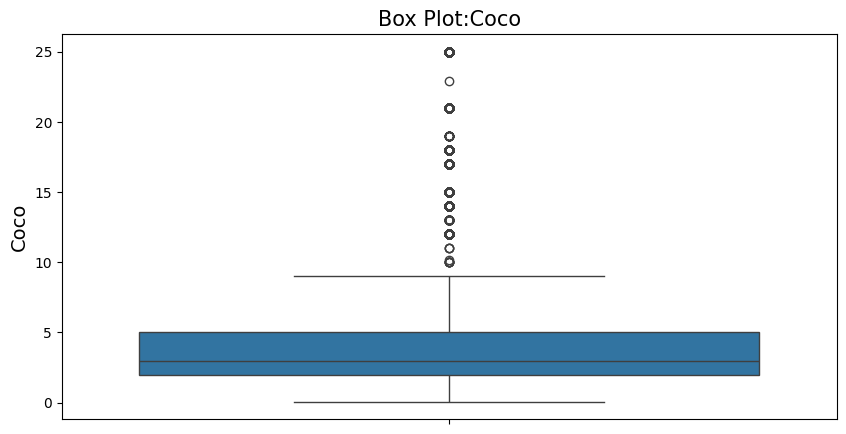

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_df.coco)
plt.title('Box Plot:Coco', fontsize=15)
plt.ylabel('Coco', fontsize=14)
plt.show()

In [ ]:
mask_ntsun = Memm_df['tsun'] > 0.0
Memm_df[mask_ntsun]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
9,2.0,1.3,95.0,0.0,230.0,10.1,24.1,1032.6,4.000000,4.0
10,2.6,1.4,92.0,0.0,230.0,10.8,25.9,1032.2,4.000000,4.0
39,0.2,-3.0,79.0,0.0,300.0,11.2,29.6,1034.0,2.000000,21.0
40,-0.2,-3.9,76.0,0.0,300.0,9.7,25.9,1034.5,7.000000,21.0
45,-2.0,-5.2,79.0,0.0,250.0,4.7,14.8,1037.4,12.060809,4.0
...,...,...,...,...,...,...,...,...,...,...
43808,0.2,-2.3,83.0,0.0,210.0,6.1,14.8,1011.5,3.000000,3.0
43811,5.5,1.0,73.0,0.0,200.0,15.8,14.8,1009.7,8.000000,3.0
43812,7.3,2.2,70.0,0.0,170.0,12.2,18.5,1009.0,37.000000,4.0
43813,8.4,2.8,68.0,0.0,200.0,11.2,20.4,1008.4,24.000000,4.0


In [ ]:
mask_tsun = Memm_df['tsun'] == 0.0
mask_prcp = Memm_df['prcp'] ==0.0
Memm_df[mask_tsun & mask_prcp]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
3,1.2,1.1,99.0,0.0,190.0,14.0,13.0,1034.1,0.0,4.0
4,0.4,0.3,99.0,0.0,200.0,19.8,14.8,1033.7,0.0,4.0
5,1.2,1.2,100.0,0.0,210.0,13.7,14.8,1033.4,0.0,4.0
6,1.4,1.3,99.0,0.0,220.0,11.9,16.7,1033.3,0.0,4.0
7,1.2,0.8,97.0,0.0,210.0,12.6,18.5,1033.1,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...
43819,1.8,1.2,96.0,0.0,200.0,24.1,27.8,1011.2,0.0,7.0
43820,2.2,1.6,96.0,0.0,210.0,23.8,27.8,1011.4,0.0,7.0
43821,2.2,1.3,94.0,0.0,210.0,19.4,27.8,1011.6,0.0,7.0
43822,2.1,1.2,94.0,0.0,200.0,16.6,29.6,1012.0,0.0,7.0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor


# Number of neighbors for LOF
n_neighbors = 20
contamination = 0.10
# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}

# Apply LOF to each feature
for feature in Memm_df.columns:
# Reshape the data for LOF
 X = Memm_df[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers in memmingen weather in {feature}: {percentage_outliers:.2f}%')

Percentage of outliers in memmingen weather in temp: 0.37%
Percentage of outliers in memmingen weather in dwpt: 0.22%
Percentage of outliers in memmingen weather in rhum: 0.04%
Percentage of outliers in memmingen weather in prcp: 0.02%
Percentage of outliers in memmingen weather in wdir: 0.04%
Percentage of outliers in memmingen weather in wspd: 0.07%
Percentage of outliers in memmingen weather in wpgt: 0.52%
Percentage of outliers in memmingen weather in pres: 0.77%
Percentage of outliers in memmingen weather in tsun: 1.51%
Percentage of outliers in memmingen weather in coco: 0.37%


NAVE BAYES FOR WEATHER DATASET

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm


# Extract features
X = Memm_df.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = gnb.var_
likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_Memm_df = Memm_df.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(Memm_df)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in Memm_df.columns:
    feature_anomalies_count = (anomalies_Memm_df[feature] != Memm_df[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")

Number of anomalies detected: 4383
Percentage of anomalies for each feature:
temp: 9.93%
dwpt: 9.94%
rhum: 9.69%
prcp: 2.75%
wdir: 9.70%
wspd: 9.83%
wpgt: 9.47%
pres: 9.95%
tsun: 4.95%
coco: 7.52%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm



# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in Memm_df.columns:
    # Extract the feature values
    X = Memm_df[[feature]].values

    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])

    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)

    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood

    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]

    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(Memm_df)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: temp
  Number of anomalies detected: 1734
  Percentage of anomalies: 3.96%
Feature: dwpt
  Number of anomalies detected: 1130
  Percentage of anomalies: 2.58%
Feature: rhum
  Number of anomalies detected: 2906
  Percentage of anomalies: 6.63%
Feature: prcp
  Number of anomalies detected: 1793
  Percentage of anomalies: 4.09%
Feature: wdir
  Number of anomalies detected: 0
  Percentage of anomalies: 0.00%
Feature: wspd
  Number of anomalies detected: 2577
  Percentage of anomalies: 5.88%
Feature: wpgt
  Number of anomalies detected: 3296
  Percentage of anomalies: 7.52%
Feature: pres
  Number of anomalies detected: 2985
  Percentage of anomalies: 6.81%
Feature: tsun
  Number of anomalies detected: 6337
  Percentage of anomalies: 14.46%
Feature: coco
  Number of anomalies detected: 3502
  Percentage of anomalies: 7.99%


AUTOENCODER FOR WEATHER DATASET

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential



#to save all features
features_auto_w = Memm_df.columns.tolist()


# DataFrame to store anomaly scores for each feature
anomaly_scores_auto_w = pd.DataFrame(index=Memm_df.index)

# Loop through each feature
for feature in features_auto_w :
    # Scale the feature data
    scaler = MinMaxScaler()
    scaled_feature_auto_w  = scaler.fit_transform(Memm_df[[feature]])

    # Define the autoencoder model
    model_auto_w  = Sequential([
        Dense(32, activation='relu', input_shape=(1,)),
        Dense(16, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model_auto_w .compile(optimizer='adam', loss='mean_squared_error')

     #Train the autoencoder
    model_auto_w.fit(scaled_feature_auto_w , scaled_feature_auto_w , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

    # Get reconstruction loss
    reconstructed_feature_auto_w  = model_auto_w.predict(scaled_feature_auto_w )
    reconstruction_loss_auto_w  = np.mean(np.square(scaled_feature_auto_w  - reconstructed_feature_auto_w ), axis=1)

    # Store the reconstruction loss (anomaly score) in the DataFrame
    anomaly_scores_auto_w [feature] = reconstruction_loss_auto_w



1370/1370 [==============================] - 3s 2ms/step


In [ ]:

print(reconstruction_loss_auto_w)
# Calculate the threshold as the 90th percentile of the reconstruction loss
threshold_auto_w = np.percentile(reconstruction_loss_auto_w, 90)

    # Identify anomalies
anomalies_auto_w = reconstruction_loss_auto_w > threshold_auto_w

for feature in features_auto_w:
    anomalies_auto_w = anomaly_scores_auto_w[feature] > threshold_auto_w
    anomaly_percentage_auto_w = np.mean(anomalies_auto_w) * 100
    print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_w:.2f}%')


    # Store the reconstruction loss (anomaly score) in the DataFrame
anomaly_scores_auto_w[feature] = reconstruction_loss_auto_w


# Combine anomaly scores with original data for easier analysis
combined_data_auto_w = pd.concat([Memm_df, anomaly_scores_auto_w.add_suffix('_anomaly_score')], axis=1)

# Save the combined data with anomaly scores
combined_data_auto_w.to_csv('Memm_df_with_anomaly_scores_auto_w.csv', index=False)

# Display the first few rows of the combined data
combined_data_auto_w.head()

[2.35596996e-07 2.35596996e-07 2.35596996e-07 ... 1.30264210e-06
 1.30264210e-06 2.35596996e-07]
Feature: temp, Anomaly Percentage: 42.66%
Feature: dwpt, Anomaly Percentage: 6.08%
Feature: rhum, Anomaly Percentage: 66.24%
Feature: prcp, Anomaly Percentage: 1.84%
Feature: wdir, Anomaly Percentage: 39.60%
Feature: wspd, Anomaly Percentage: 20.24%
Feature: wpgt, Anomaly Percentage: 51.05%
Feature: pres, Anomaly Percentage: 71.57%
Feature: tsun, Anomaly Percentage: 31.85%
Feature: coco, Anomaly Percentage: 7.89%


,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco,temp_anomaly_score,dwpt_anomaly_score,rhum_anomaly_score,prcp_anomaly_score,wdir_anomaly_score,wspd_anomaly_score,wpgt_anomaly_score,pres_anomaly_score,tsun_anomaly_score,coco_anomaly_score
0,1.2,1.2,100.0,0.0,170.0,10.1,13.0,1034.9,-2.451226,4.0,9.324778e-07,3.435857e-07,0.000094,1.146404e-08,3.768209e-06,1.661264e-09,0.000003,3.589672e-09,3.385785e-06,2.355970e-07
1,0.9,0.9,100.0,0.0,190.0,10.4,13.0,1034.6,-2.928980,4.0,5.617657e-07,2.956390e-07,0.000094,1.146404e-08,1.799805e-08,1.334457e-07,0.000003,3.721489e-06,1.138464e-06,2.355970e-07
2,1.1,1.1,100.0,0.0,180.0,13.7,13.0,1034.4,-3.544110,4.0,7.883497e-07,3.258296e-07,0.000094,1.146404e-08,1.083795e-06,4.497067e-08,0.000003,5.914410e-06,1.349616e-07,2.355970e-07
3,1.2,1.1,99.0,0.0,190.0,14.0,13.0,1034.1,0.000000,4.0,9.324778e-07,3.258296e-07,0.000006,1.146404e-08,1.799805e-08,4.589586e-08,0.000003,2.136493e-06,1.021936e-06,2.355970e-07
4,0.4,0.3,99.0,0.0,200.0,19.8,14.8,1033.7,0.000000,4.0,2.571280e-07,2.516262e-07,0.000006,1.146404e-08,3.497821e-07,1.202994e-06,0.000001,6.732971e-08,1.021936e-06,2.355970e-07


XGBOOST FOR WEATHER DATASET

In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Sample Data (Replace with your dataset)
# Assuming a dataframe with 100 rows and 10 features


# Define anomaly detection function
def detect_anomalies(Mun_df):
    anomalies = pd.DataFrame(index=Mun_df.index)
    anomaly_percentages = {}

    for feature in Mun_df.columns:
        X = Mun_df.drop(columns=[feature])
        y = Mun_df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(Mun_df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(Mun_df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(Memm_df)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")


Feature: temp
Threshold: 0.3040
Anomalies detected: 1681/43824 (3.84%)
----------------------------------------
Feature: dwpt
Threshold: 0.2843
Anomalies detected: 1607/43824 (3.67%)
----------------------------------------
Feature: rhum
Threshold: 2.6785
Anomalies detected: 2052/43824 (4.68%)
----------------------------------------
Feature: prcp
Threshold: 0.6429
Anomalies detected: 1130/43824 (2.58%)
----------------------------------------
Feature: wdir
Threshold: 145.3580
Anomalies detected: 2590/43824 (5.91%)
----------------------------------------
Feature: wspd
Threshold: 4.9646
Anomalies detected: 2113/43824 (4.82%)
----------------------------------------
Feature: wpgt
Threshold: 7.7526
Anomalies detected: 2048/43824 (4.67%)
----------------------------------------
Feature: pres
Threshold: 12.6051
Anomalies detected: 2238/43824 (5.11%)
----------------------------------------
Feature: tsun
Threshold: 26.7772
Anomalies detected: 2647/43824 (6.04%)
-----------------------------

IRRADIATION DATASET


In [ ]:
import pandas as pd
import requests
#importing irradiation data for Meiningen
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=irradiationdataforcities&start=2019-01-01&end=2023-12-31&cityName=memmingen"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    data = response.json()

    # Convert the data to a DataFrame
    memm_irrad = pd.DataFrame.from_dict(data, orient='index')


else:
    print("Failed to fetch data. Status code:", response.status_code)


In [ ]:
 memm_irrad.head(2)

,time,Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability,cityName
1546300800000,2019-01-01 00:00:00,2019-01-01T00:00:00.0/2019-01-01T00:15:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,memmingen
1546301700000,2019-01-01 00:15:00,2019-01-01T00:15:00.0/2019-01-01T00:30:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,memmingen


In [ ]:

# drop unwanted columns
Memm_clean_df = memm_irrad.drop(columns = ["time", "Observation period", "Reliability", "cityName"])
memm_irrad.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   time                175296 non-null  object 
 1   Observation period  175296 non-null  object 
 2   TOA                 175296 non-null  object 
 3   Clear sky GHI       175296 non-null  object 
 4   Clear sky BHI       175296 non-null  object 
 5   Clear sky DHI       175296 non-null  object 
 6   Clear sky BNI       175296 non-null  object 
 7   GHI                 175296 non-null  float64
 8   BHI                 175296 non-null  object 
 9   DHI                 175296 non-null  object 
 10  BNI                 175296 non-null  object 
 11  Reliability         175296 non-null  object 
 12  cityName            175296 non-null  object 
dtypes: float64(1), object(12)
memory usage: 18.7+ MB


In [ ]:
#Get the percentage of null values in the dataset
Memm_clean_df.isnull().sum() /len(memm_irrad) *(100)

TOA              0.0
Clear sky GHI    0.0
Clear sky BHI    0.0
Clear sky DHI    0.0
Clear sky BNI    0.0
GHI              0.0
BHI              0.0
DHI              0.0
BNI              0.0
dtype: float64

In [ ]:
Memm_clean_df

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546302600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546303500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546304400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
1704062700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704063600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704064500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704065400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


In [ ]:
Memm_clean = Memm_clean_df.select_dtypes(include=['object']).astype('float')
Memm_clean["GHI"] = Memm_clean_df["GHI"]
Memm_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TOA            175296 non-null  float64
 1   Clear sky GHI  175296 non-null  float64
 2   Clear sky BHI  175296 non-null  float64
 3   Clear sky DHI  175296 non-null  float64
 4   Clear sky BNI  175296 non-null  float64
 5   BHI            175296 non-null  float64
 6   DHI            175296 non-null  float64
 7   BNI            175296 non-null  float64
 8   GHI            175296 non-null  float64
dtypes: float64(9)
memory usage: 13.4+ MB


In [ ]:

# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = Memm_clean_df.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
mask = Memm_clean["GHI"] ==0.0
(len(Memm_clean[mask])/len(Memm_clean)) *100


48.83739503468419

In [51]:
Memm_clean.describe()

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,BHI,DHI,BNI,GHI
count,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000
mean,73.424775,53.426361,41.807054,11.619307,82.403378,21.381027,16.286927,41.840307,37.667954
std,94.227971,72.197021,59.241193,14.859028,93.232810,44.404318,24.437712,71.641128,58.894612
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.559700,0.659200,0.046500,0.587950,0.820000,0.000000,0.517750,0.000000,0.559050
75%,139.498925,99.078750,75.374075,21.531225,185.091025,14.848325,25.428000,56.316550,56.841775
max,299.808400,246.149700,224.452200,115.452100,263.321200,224.452200,133.658700,263.321200,246.149700


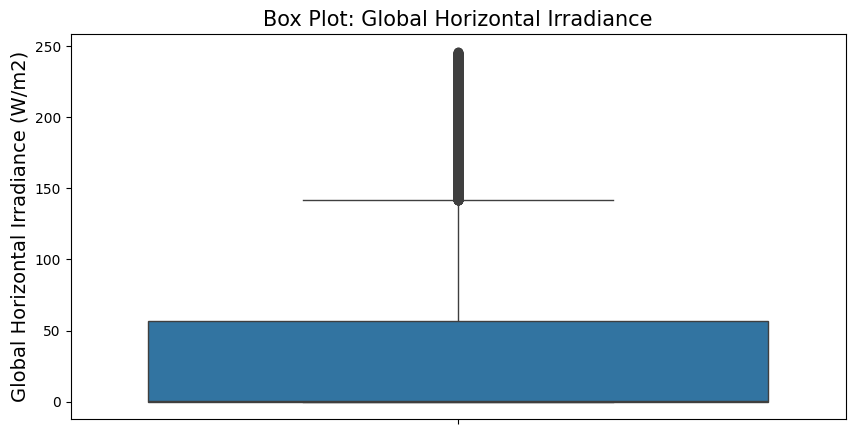

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_clean_df.GHI)
plt.title('Box Plot: Global Horizontal Irradiance', fontsize=15)
plt.ylabel('Global Horizontal Irradiance (W/m2)', fontsize=14)
plt.show()

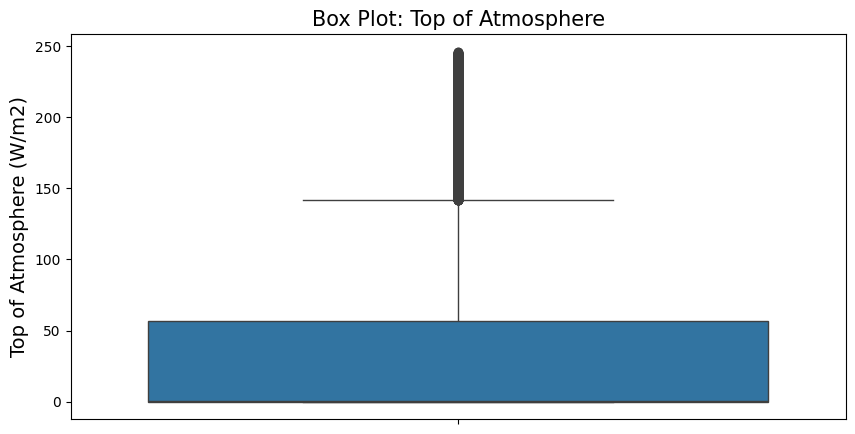

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Memm_clean_df.GHI)
plt.title('Box Plot: Top of Atmosphere', fontsize=15)
plt.ylabel('Top of Atmosphere (W/m2)', fontsize=14)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor

# Number of neighbors for LOF
n_neighbors = 20
contamination = 0.10
# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}

# Apply LOF to each feature
for feature in Memm_clean_df.columns:
# Reshape the data for LOF
 X = Memm_clean_df[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers memmingen irradiation in {feature}: {percentage_outliers:.2f}%')

Percentage of outliers memmingen irradiation in TOA: 0.05%
Percentage of outliers memmingen irradiation in Clear sky GHI: 0.01%
Percentage of outliers memmingen irradiation in Clear sky BHI: 0.07%
Percentage of outliers memmingen irradiation in Clear sky DHI: 0.02%
Percentage of outliers memmingen irradiation in Clear sky BNI: 0.01%
Percentage of outliers memmingen irradiation in GHI: 0.01%
Percentage of outliers memmingen irradiation in BHI: 0.17%
Percentage of outliers memmingen irradiation in DHI: 0.01%
Percentage of outliers memmingen irradiation in BNI: 0.09%


USING NAIVE BAYES FOR IRRADIATION DATASET

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm

# Assuming clean_Osna_Irrad is your DataFrame loaded from your dataset
# Example steps to handle data types and missing values

# Step 1: Check and Convert Data Types
# Convert all columns to numeric (float64)
Memm_clean_df = Memm_clean_df.apply(pd.to_numeric, errors='coerce')

# Step 2: Handle Missing Values
Memm_clean_df = Memm_clean_df.dropna()  # Drop rows with NaN values

# Extract features
X = Memm_clean_df.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = np.var(X, axis=0) + 1e-9  # Adding a small value for numerical stability

likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_Memm_clean_df = Memm_clean_df.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(Memm_clean_df)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in Memm_clean_df.columns:
    feature_anomalies_count = (anomalies_Memm_clean_df[feature] != Memm_clean_df[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Number of anomalies detected: 17530
Percentage of anomalies for each feature:
TOA: 10.00%
Clear sky GHI: 10.00%
Clear sky BHI: 10.00%
Clear sky DHI: 10.00%
Clear sky BNI: 10.00%
GHI: 10.00%
BHI: 9.97%
DHI: 10.00%
BNI: 9.97%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm


# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in Memm_clean.columns:
    # Extract the feature values
    X = Memm_clean[[feature]].values

    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])

    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)

    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood

    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]

    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(Memm_clean)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: TOA
  Number of anomalies detected: 16077
  Percentage of anomalies: 9.17%
Feature: Clear sky GHI
  Number of anomalies detected: 16900
  Percentage of anomalies: 9.64%
Feature: Clear sky BHI
  Number of anomalies detected: 17182
  Percentage of anomalies: 9.80%
Feature: Clear sky DHI
  Number of anomalies detected: 13365
  Percentage of anomalies: 7.62%
Feature: Clear sky BNI
  Number of anomalies detected: 6220
  Percentage of anomalies: 3.55%
Feature: BHI
  Number of anomalies detected: 16750
  Percentage of anomalies: 9.56%
Feature: DHI
  Number of anomalies detected: 15219
  Percentage of anomalies: 8.68%
Feature: BNI
  Number of anomalies detected: 19770
  Percentage of anomalies: 11.28%
Feature: GHI
  Number of anomalies detected: 17194
  Percentage of anomalies: 9.81%


AUTOENCODER FOR IRRADIATION

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential



#to save all features
features_auto_i = Memm_clean_df.columns.tolist()


# DataFrame to store anomaly scores for each feature
anomaly_scores_auto_i = pd.DataFrame(index=Memm_clean_df.index)

# Loop through each feature
for feature in features_auto_i :
    # Scale the feature data
    scaler = MinMaxScaler()
    scaled_feature_auto_i  = scaler.fit_transform(Memm_clean_df[[feature]])

    # Define the autoencoder model
    model_auto_i  = Sequential([
        Dense(32, activation='relu', input_shape=(1,)),
        Dense(16, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model_auto_i .compile(optimizer='adam', loss='mean_squared_error')

     #Train the autoencoder
    model_auto_i.fit(scaled_feature_auto_i , scaled_feature_auto_i , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

    # Get reconstruction loss
    reconstructed_feature_auto_i  = model_auto_i.predict(scaled_feature_auto_i)
    reconstruction_loss_auto_i  = np.mean(np.square(scaled_feature_auto_i  - reconstructed_feature_auto_i), axis=1)

    # Store the reconstruction loss (anomaly score) in the DataFrame
    anomaly_scores_auto_i [feature] = reconstruction_loss_auto_i



5478/5478 [==============================] - 8s 2ms/step


In [ ]:

print(reconstruction_loss_auto_i)
# Calculate the threshold as the 90th percentile of the reconstruction loss
threshold_auto_i = np.percentile(reconstruction_loss_auto_i, 90)

    # Identify anomalies
anomalies_auto_i = reconstruction_loss_auto_i > threshold_auto_i

for feature in features_auto_i:
    anomalies_auto_i = anomaly_scores_auto_i[feature] > threshold_auto_i
    anomaly_percentage_auto_i = np.mean(anomalies_auto_i) * 100
    print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_i:.2f}%')


    # Store the reconstruction loss (anomaly score) in the DataFrame
anomaly_scores_auto_i[feature] = reconstruction_loss_auto_i


# Combine anomaly scores with original data for easier analysis
combined_data_auto_i = pd.concat([Memm_clean_df, anomaly_scores_auto_i.add_suffix('_anomaly_score')], axis=1)

# Save the combined data with anomaly scores
combined_data_auto_i.to_csv('Memm_clean_df_with_anomaly_scores_auto_i.csv', index=False)

# Display the first few rows of the combined data
combined_data_auto_i.head()






[4.69239719e-08 4.69239719e-08 4.69239719e-08 ... 4.69239719e-08
 4.69239719e-08 4.69239719e-08]
Feature: TOA, Anomaly Percentage: 33.25%
Feature: Clear sky GHI, Anomaly Percentage: 22.86%
Feature: Clear sky BHI, Anomaly Percentage: 22.45%
Feature: Clear sky DHI, Anomaly Percentage: 14.70%
Feature: Clear sky BNI, Anomaly Percentage: 7.48%
Feature: GHI, Anomaly Percentage: 17.24%
Feature: BHI, Anomaly Percentage: 7.08%
Feature: DHI, Anomaly Percentage: 14.44%
Feature: BNI, Anomaly Percentage: 10.00%


,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,TOA_anomaly_score,Clear sky GHI_anomaly_score,Clear sky BHI_anomaly_score,Clear sky DHI_anomaly_score,Clear sky BNI_anomaly_score,GHI_anomaly_score,BHI_anomaly_score,DHI_anomaly_score,BNI_anomaly_score
1546300800000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.504444e-07,1.389433e-08,6.049954e-08,1.962373e-08,2.934096e-08,5.337987e-09,9.725137e-09,1.400487e-08,4.692397e-08
1546301700000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.504444e-07,1.389433e-08,6.049954e-08,1.962373e-08,2.934096e-08,5.337987e-09,9.725137e-09,1.400487e-08,4.692397e-08
1546302600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.504444e-07,1.389433e-08,6.049954e-08,1.962373e-08,2.934096e-08,5.337987e-09,9.725137e-09,1.400487e-08,4.692397e-08
1546303500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.504444e-07,1.389433e-08,6.049954e-08,1.962373e-08,2.934096e-08,5.337987e-09,9.725137e-09,1.400487e-08,4.692397e-08
1546304400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.504444e-07,1.389433e-08,6.049954e-08,1.962373e-08,2.934096e-08,5.337987e-09,9.725137e-09,1.400487e-08,4.692397e-08


APPLYING XGBOOST ON IRRADIATION

In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Sample Data (Replace with your dataset)
# Assuming a dataframe with 100 rows and 10 features


# Define anomaly detection function
def detect_anomalies(Mun_df):
    anomalies = pd.DataFrame(index=Mun_df.index)
    anomaly_percentages = {}

    for feature in Mun_df.columns:
        X = Mun_df.drop(columns=[feature])
        y = Mun_df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(Mun_df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(Mun_df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(Memm_clean)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")
